Pre-compiling and executing loop code via Numba...
Simulation completed natively in 24.29 seconds!
Streaming data metrics into 'polymer_exact_match_vectors_15000.csv'...
  [File Processing Progress]: 10% Complete.
  [File Processing Progress]: 20% Complete.
  [File Processing Progress]: 30% Complete.
  [File Processing Progress]: 40% Complete.
  [File Processing Progress]: 50% Complete.
  [File Processing Progress]: 60% Complete.
  [File Processing Progress]: 70% Complete.
  [File Processing Progress]: 80% Complete.
  [File Processing Progress]: 90% Complete.
  [File Processing Progress]: 100% Complete.
--> File output verification finalized. Saved: 1997 snapshot configurations.
Final Global Simulation RMS = 22.87793


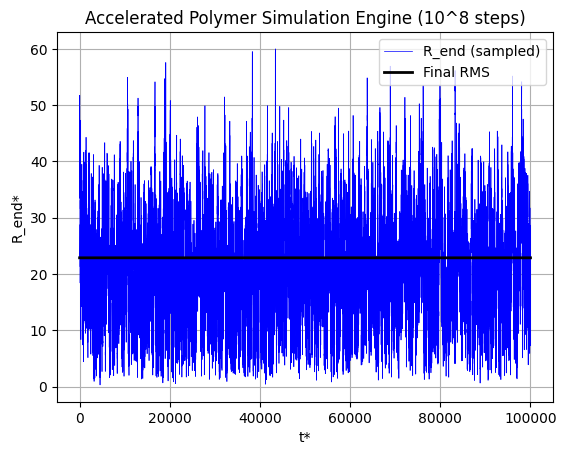

In [7]:
import random
import math
import csv
import time
import numpy as np
import matplotlib.pyplot as plt
from numba import njit

# =====================================================================
# 1. HIGH-PERFORMANCE COMPILED MATHEMATICAL CORE
# =====================================================================
@njit(fastmath=True)
def run_simulation_core(v, dt, total_time, start_time, interval_time, max_configs):
    Nsteps = int(total_time / dt)
    v_sq = v * v
    v_sq_3 = 3 * v_sq
    B = math.sqrt(6 * dt)

    # Initialize position scalars
    x1 = y1 = z1 = 0.0
    x2 = math.sqrt(v)
    y2 = z2 = 0.0
    x3 = 2 * math.sqrt(v)
    x4 = 3 * math.sqrt(v)
    x5 = 4 * math.sqrt(v)
    x6 = 5 * math.sqrt(v)
    y3 = y4 = y5 = y6 = z3 = z4 = z5 = z6 = 0.0

    # Downsampled plot storage arrays
    plot_steps = Nsteps // 1000
    time_arr = np.zeros(plot_steps, dtype=np.float64)
    R_end_arr = np.zeros(plot_steps, dtype=np.float64)
    plot_idx = 0

    # Exact sizing for the requested 10,000 configurations
    # Array maps to columns: [Config_No, Time, Time_Steps, Cumulative_RMS, Rx1, Ry1, Rz1, ..., Rx5, Ry5, Rz5]
    config_data = np.zeros((max_configs, 19), dtype=np.float64)

    start_step = int(start_time / dt)
    interval_steps = int(interval_time / dt)
    configs_saved = 0

    t = 0.0
    sum_sq = 0.0

    for step in range(Nsteps):
        current_step = step + 1

        # 1. Coordinate Differences (Spring Vectors)
        Rx_1, Ry_1, Rz_1 = x2 - x1, y2 - y1, z2 - z1
        Rx_2, Ry_2, Rz_2 = x3 - x2, y3 - y2, z3 - z2
        Rx_3, Ry_3, Rz_3 = x4 - x3, y4 - y3, z4 - z3
        Rx_4, Ry_4, Rz_4 = x5 - x4, y5 - y4, z5 - z4
        Rx_5, Ry_5, Rz_5 = x6 - x5, y6 - y5, z6 - z5

        # 2. Squared Magnitudes
        r2_sq1 = Rx_1*Rx_1 + Ry_1*Ry_1 + Rz_1*Rz_1
        r2_sq2 = Rx_2*Rx_2 + Ry_2*Ry_2 + Rz_2*Rz_2
        r2_sq3 = Rx_3*Rx_3 + Ry_3*Ry_3 + Rz_3*Rz_3
        r2_sq4 = Rx_4*Rx_4 + Ry_4*Ry_4 + Rz_4*Rz_4
        r2_sq5 = Rx_5*Rx_5 + Ry_5*Ry_5 + Rz_5*Rz_5

        # 3. Dynamic Coefficients
        C1 = (v_sq_3 - r2_sq1) / (v * (v_sq - r2_sq1))
        C2 = (v_sq_3 - r2_sq2) / (v * (v_sq - r2_sq2))
        C3 = (v_sq_3 - r2_sq3) / (v * (v_sq - r2_sq3))
        C4 = (v_sq_3 - r2_sq4) / (v * (v_sq - r2_sq4))
        C5 = (v_sq_3 - r2_sq5) / (v * (v_sq - r2_sq5))

        # 4. Forces Calculation
        Fx_1, Fy_1, Fz_1 = C1 * Rx_1, C1 * Ry_1, C1 * Rz_1
        Fx_2, Fy_2, Fz_2 = -C1*Rx_1 + C2*Rx_2, -C1*Ry_1 + C2*Ry_2, -C1*Rz_1 + C2*Rz_2
        Fx_3, Fy_3, Fz_3 = C3*Rx_3 - C2*Rx_2, C3*Ry_3 - C2*Ry_2, C3*Rz_3 - C2*Rz_2
        Fx_4, Fy_4, Fz_4 = C4*Rx_4 - C3*Rx_3, C4*Ry_4 - C3*Ry_3, C4*Rz_4 - C3*Rz_3
        Fx_5, Fy_5, Fz_5 = C5*Rx_5 - C4*Rx_4, C5*Ry_5 - C4*Ry_4, C5*Rz_5 - C4*Rz_4
        Fx_6, Fy_6, Fz_6 = -C5*Rx_5, -C5*Ry_5, -C5*Rz_5

        # 5. Native Numba-Optimized Random Positions Integration
        x1 += B * (2 * random.random() - 1) + Fx_1 * dt
        y1 += B * (2 * random.random() - 1) + Fy_1 * dt
        z1 += B * (2 * random.random() - 1) + Fz_1 * dt

        x2 += B * (2 * random.random() - 1) + Fx_2 * dt
        y2 += B * (2 * random.random() - 1) + Fy_2 * dt
        z2 += B * (2 * random.random() - 1) + Fz_2 * dt

        x3 += B * (2 * random.random() - 1) + Fx_3 * dt
        y3 += B * (2 * random.random() - 1) + Fy_3 * dt
        z3 += B * (2 * random.random() - 1) + Fz_3 * dt

        x4 += B * (2 * random.random() - 1) + Fx_4 * dt
        y4 += B * (2 * random.random() - 1) + Fy_4 * dt
        z4 += B * (2 * random.random() - 1) + Fz_4 * dt

        x5 += B * (2 * random.random() - 1) + Fx_5 * dt
        y5 += B * (2 * random.random() - 1) + Fy_5 * dt
        z5 += B * (2 * random.random() - 1) + Fz_5 * dt

        x6 += B * (2 * random.random() - 1) + Fx_6 * dt
        y6 += B * (2 * random.random() - 1) + Fy_6 * dt
        z6 += B * (2 * random.random() - 1) + Fz_6 * dt

        # 6. Distance Tracking
        R_end = math.sqrt((x6-x1)**2 + (y6-y1)**2 + (z6-z1)**2)
        sum_sq += R_end * R_end
        t += dt

        # Plot Data Compilation (Every 1000 steps)
        if current_step % 1000 == 0 and plot_idx < plot_steps:
            R_end_arr[plot_idx] = R_end
            time_arr[plot_idx] = t
            plot_idx += 1

        # 7. Checkpoint Storage Selection
        if configs_saved < max_configs:
            if (configs_saved == 0 and current_step == start_step) or \
               (configs_saved > 0 and (current_step - start_step) % interval_steps == 0):

                rms_val = math.sqrt(sum_sq / current_step)

                # Directly assign data parameters to row
                config_data[configs_saved, 0] = configs_saved + 1
                config_data[configs_saved, 1] = t
                config_data[configs_saved, 2] = current_step
                config_data[configs_saved, 3] = rms_val

                config_data[configs_saved, 4],  config_data[configs_saved, 5],  config_data[configs_saved, 6]  = Rx_1, Ry_1, Rz_1
                config_data[configs_saved, 7],  config_data[configs_saved, 8],  config_data[configs_saved, 9]  = Rx_2, Ry_2, Rz_2
                config_data[configs_saved, 10], config_data[configs_saved, 11], config_data[configs_saved, 12] = Rx_3, Ry_3, Rz_3
                config_data[configs_saved, 13], config_data[configs_saved, 14], config_data[configs_saved, 15] = Rx_4, Ry_4, Rz_4
                config_data[configs_saved, 16], config_data[configs_saved, 17], config_data[configs_saved, 18] = Rx_5, Ry_5, Rz_5

                configs_saved += 1

    final_RMS = math.sqrt(sum_sq / Nsteps)
    return time_arr, R_end_arr, config_data, final_RMS, configs_saved

# =====================================================================
# 2. INTERPRETER SYSTEM EXECUTIVE WRAPPER
# =====================================================================
if __name__ == "__main__":
    v = 100
    dt = 0.001
    total_time = 100000

    # Checkpoint Definitions
    start_time = 200.0
    interval_time = 50.0
    max_configs = 15000
    csv_filename = "polymer_exact_match_vectors_15000.csv"

    print("Pre-compiling and executing loop code via Numba...")
    start_perf = time.time()

    # Fire off execution
    time_list, R_end_list, config_data, final_RMS, configs_saved = run_simulation_core(
        v, dt, total_time, start_time, interval_time, max_configs
    )

    print(f"Simulation completed natively in {time.time() - start_perf:.2f} seconds!")

    # Live streaming intermediate arrays down into the target CSV File with visual status updates
    print(f"Streaming data metrics into '{csv_filename}'...")

    fieldnames = [
        "Configuration_No", "Time", "Time_Steps", "Cumulative_RMS",
        "Spring1_Rx", "Spring1_Ry", "Spring1_Rz",
        "Spring2_Rx", "Spring2_Ry", "Spring2_Rz",
        "Spring3_Rx", "Spring3_Ry", "Spring3_Rz",
        "Spring4_Rx", "Spring4_Ry", "Spring4_Rz",
        "Spring5_Rx", "Spring5_Ry", "Spring5_Rz"
    ]

    # Progress check thresholds setup
    checkpoint_percentages = [10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
    next_check_idx = 0

    with open(csv_filename, mode='w', newline='') as csv_file:
        writer = csv.writer(csv_file)
        writer.writerow(fieldnames)  # Write header matrix column configuration

        for idx in range(configs_saved):
            writer.writerow(config_data[idx])

            # Active runtime console telemetry tracking matching specified intervals
            current_pct = int(((idx + 1) / configs_saved) * 100)
            if next_check_idx < len(checkpoint_percentages) and current_pct >= checkpoint_percentages[next_check_idx]:
                print(f"  [File Processing Progress]: {checkpoint_percentages[next_check_idx]}% Complete.")
                next_check_idx += 1

    print(f"--> File output verification finalized. Saved: {configs_saved} snapshot configurations.")
    print(f"Final Global Simulation RMS = {final_RMS:.5f}")

    # 3. Visualization Mapping Layout Setup
    plt.plot(time_list, R_end_list, 'b', linewidth=0.5, label="R_end (sampled)")
    plt.plot(time_list, [final_RMS]*len(time_list), 'k', linewidth=2, label="Final RMS")
    plt.xlabel("t*")
    plt.ylabel("R_end*")
    plt.title("Accelerated Polymer Simulation Engine (10^8 steps)")
    plt.grid(True)
    plt.legend()
    plt.show()

In [9]:
import numpy as np
import pandas as pd

# =====================================================
# PATH CONFIGURATION
# =====================================================
csv_filename = "polymer_exact_match_vectors_15000.csv"

print(f"Reading dataset: {csv_filename} ...")
df = pd.read_csv(csv_filename)

# Check the layout of your incoming CSV column names.
# If your CSV uses 'Spring1_Rx', 'Spring1_Ry' (from the simulation script),
# this block dynamically reshapes it to match your calculation architecture.
if "Spring1_Rx" in df.columns:
    print("Detected wide-format simulation columns. Restructuring for matrix operations...")
    records = []
    for idx, row in df.iterrows():
        config_id = row.get("Configuration_No", idx + 1)
        for s in range(1, 6):
            records.append({
                "Configuration_ID": int(config_id),
                "Spring_ID": s,
                "Qx": row[f"Spring{s}_Rx"],
                "Qy": row[f"Spring{s}_Ry"],
                "Qz": row[f"Spring{s}_Rz"]
            })
    df = pd.DataFrame(records)

# Ensure the rows are strictly sorted by Configuration and Spring order
df = df.sort_values(["Configuration_ID", "Spring_ID"])

num_configs = df["Configuration_ID"].nunique()
num_springs = df["Spring_ID"].nunique()

print(f"Configurations found : {num_configs}")
print(f"Springs per polymer  : {num_springs}")

# =====================================================
# VECTORIZED END-TO-END RECONSTRUCTION
# =====================================================
# Extract raw components: Shape (Num_configs * 5, 3)
q_components = df[["Qx", "Qy", "Qz"]].values

# Reshape into a 3D matrix: Shape (Num_configs, 5 springs, 3 components)
spring_matrix = q_components.reshape(num_configs, num_springs, 3)

# Sum across axis 1 (the 5 springs) to get total end-to-end vector for each chain
r_ee_vectors = spring_matrix.sum(axis=1)

# Calculate the magnitude of the end-to-end vector for each configuration
r_ee_magnitudes = np.linalg.norm(r_ee_vectors, axis=1)

# =====================================================
# STEP-WISE INCREMENT ANALYSIS (10 Clean Steps)
# =====================================================
print("\n" + "=" * 65)
print(f"{'Configs Evaluated':<20} | {'Mean <R>':<12} | {'Mean <R^2>':<12} | {'RMS Distance':<12}")
print("=" * 65)

# CHANGED: Generates exactly 10 checking points spanning your dataset (e.g., 1000, 2000... 10000)
# If you want specific custom indices instead, swap this line for: step_sizes = [1500, 3000, 4500, 6000]
step_sizes = np.linspace(num_configs // 10, num_configs, 10, dtype=np.int64)

for subset_limit in step_sizes:
    # Slice the magnitudes up to the current subset index
    subset_mags = r_ee_magnitudes[:subset_limit]

    # Calculate step metrics
    avg_R_ee = np.mean(subset_mags)
    mean_square_R_ee = np.mean(subset_mags ** 2)
    rms_R_ee = np.sqrt(mean_square_R_ee)

    print(f"First {subset_limit:<14} | {avg_R_ee:<12.4f} | {mean_square_R_ee:<12.4f} | {rms_R_ee:<12.4f}")

print("=" * 65)

print("=" * 65)

Reading dataset: polymer_exact_match_vectors_15000.csv ...
Detected wide-format simulation columns. Restructuring for matrix operations...
Configurations found : 1997
Springs per polymer  : 5

Configs Evaluated    | Mean <R>     | Mean <R^2>   | RMS Distance
First 199            | 21.1889      | 515.8922     | 22.7133     
First 398            | 20.9784      | 512.8584     | 22.6464     
First 598            | 20.8913      | 509.6666     | 22.5758     
First 798            | 20.5441      | 497.6475     | 22.3080     
First 998            | 20.9414      | 514.9574     | 22.6927     
First 1197           | 20.8141      | 506.9374     | 22.5153     
First 1397           | 20.8440      | 509.3269     | 22.5683     
First 1597           | 21.0540      | 519.2236     | 22.7865     
First 1797           | 21.0289      | 517.2655     | 22.7435     
First 1997           | 21.0665      | 519.6674     | 22.7962     


In [4]:
"""
polymer_training_data_step5.py
===============================================================
WHAT THIS SCRIPT DOES
-----------------------
Reads the wide-format 10,000 equilibrium spring configurations from
the previous simulation, runs EXACTLY 5 full deterministic
Brownian-dynamics steps using the EXPLICIT scheme (noise turned OFF)
per configuration, and saves the result as a neural-network training dataset.
"""

import numpy as np
import math
import pandas as pd
from numba import njit

# ================================================================
# PARAMETERS  (must match the BD simulation that made the CSV)
# ================================================================
v       = 100.0   # FENE max extensibility Q_max
dt      = 0.001   # time step
N_STEPS = 5       # how many BD steps per training pair

# MATCHED: Target the wide-format spring vector dataset directly
input_csv  = "polymer_exact_match_vectors_15000.csv"
output_csv = "polymer_training_dataset_step5.csv"


# ================================================================
# LOAD EQUILIBRIUM CONFIGURATIONS (Wide Format to Matrix Space)
# ================================================================
print(f"Reading {input_csv} ...")
df_in = pd.read_csv(input_csv)

num_configs = len(df_in)
print(f"Configurations found : {num_configs}")

# Parse wide-format tracking columns ["Spring1_Rx", "Spring1_Ry", ...] directly into (N, 5, 3) matrix
initial_springs = np.zeros((num_configs, 5, 3), dtype=np.float64)

for s in range(1, 6):
    initial_springs[:, s-1, 0] = df_in[f"Spring{s}_Rx"].values
    initial_springs[:, s-1, 1] = df_in[f"Spring{s}_Ry"].values
    initial_springs[:, s-1, 2] = df_in[f"Spring{s}_Rz"].values

print(f"Spring matrix shape  : {initial_springs.shape}")  # (10000, 5, 3)


# ================================================================
# NUMBA KERNELS
# ================================================================

@njit(inline='always')
def spring_coeff(r2, v):
    """
    FENE spring coefficient:
        C(r^2) = v^2 / (v^2 - r^2)
    Denominator clamped to prevent blow-up near full extension.
    """
    denom = v * v - r2
    if denom < 1e-6:
        denom = 1e-6
    return (v * v) / denom


# ================================================================
# DETERMINISTIC PROPAGATION CORE  (Numba JIT - Explicit Method)
# ================================================================
@njit
def propagate_spring_chains(initial_springs, num_configs, dt, v, n_steps):
    """
    Returns
    -------
    Q_initial : (num_configs, 5, 3) -- connector vectors at t=0
    Q_final   : (num_configs, 5, 3) -- connector vectors at t=n_steps * dt
    """
    Q_initial = np.zeros((num_configs, 5, 3))
    Q_final   = np.zeros((num_configs, 5, 3))

    # Internal temporary connector tracking registers
    Qs = np.zeros((5, 3))
    Cs = np.zeros(5)

    for c in range(num_configs):

        # ---- Copy raw starting spring vectors into registers ----
        for i in range(5):
            Qs[i, 0] = initial_springs[c, i, 0]
            Qs[i, 1] = initial_springs[c, i, 1]
            Qs[i, 2] = initial_springs[c, i, 2]

            # Store features inside mapping inputs (X)
            Q_initial[c, i, 0] = Qs[i, 0]
            Q_initial[c, i, 1] = Qs[i, 1]
            Q_initial[c, i, 2] = Qs[i, 2]

        # =====================================================
        # n_steps DETERMINISTIC EXPLICIT EM STEPS (noise OFF)
        # =====================================================
        for step in range(n_steps):

            # -------------------------------------------------
            # 1. Compute current FENE spring coefficients
            # -------------------------------------------------
            for i in range(5):
                r2 = Qs[i, 0]**2 + Qs[i, 1]**2 + Qs[i, 2]**2
                Cs[i] = spring_coeff(r2, v)

            # -------------------------------------------------
            # 2. Compute Connector Forces First
            # -------------------------------------------------
            forces = np.zeros((5, 3))
            for i in range(5):
                if i == 0:
                    forces[i, 0] = Cs[1]*Qs[1, 0] - 2.0*Cs[0]*Qs[0, 0]
                    forces[i, 1] = Cs[1]*Qs[1, 1] - 2.0*Cs[0]*Qs[0, 1]
                    forces[i, 2] = Cs[1]*Qs[1, 2] - 2.0*Cs[0]*Qs[0, 2]
                elif i == 4:
                    forces[i, 0] = -2.0*Cs[4]*Qs[4, 0] + Cs[3]*Qs[3, 0]
                    forces[i, 1] = -2.0*Cs[4]*Qs[4, 1] + Cs[3]*Qs[3, 1]
                    forces[i, 2] = -2.0*Cs[4]*Qs[4, 2] + Cs[3]*Qs[3, 2]
                else:
                    forces[i, 0] = (Cs[i+1]*Qs[i+1, 0] - 2.0*Cs[i]*Qs[i, 0] + Cs[i-1]*Qs[i-1, 0])
                    forces[i, 1] = (Cs[i+1]*Qs[i+1, 1] - 2.0*Cs[i]*Qs[i, 1] + Cs[i-1]*Qs[i-1, 1])
                    forces[i, 2] = (Cs[i+1]*Qs[i+1, 2] - 2.0*Cs[i]*Qs[i, 2] + Cs[i-1]*Qs[i-1, 2])

            # FIXED INDENTATION: Update coordinates AFTER calculating all vectors across the chain
            for i in range(5):
                Qs[i, 0] += dt * forces[i, 0]
                Qs[i, 1] += dt * forces[i, 1]
                Qs[i, 2] += dt * forces[i, 2]

                # Explicit Physical Boundary Safety Guard
                q_mag = math.sqrt(Qs[i, 0]**2 + Qs[i, 1]**2 + Qs[i, 2]**2)
                if q_mag >= v:
                    scale = (v * 0.9999) / q_mag
                    Qs[i, 0] *= scale
                    Qs[i, 1] *= scale
                    Qs[i, 2] *= scale

        # ---- Record final deterministic target vector (y) ----
        for i in range(5):
            Q_final[c, i, 0] = Qs[i, 0]
            Q_final[c, i, 1] = Qs[i, 1]
            Q_final[c, i, 2] = Qs[i, 2]

        if (c + 1) % 5000 == 0:
            print("Processed:", c + 1, "/", num_configs, "chains")

    return Q_initial, Q_final


# ================================================================
# RUN DATA GENERATION
# ================================================================
print(f"\nGenerating explicit deterministic {N_STEPS}-step training pairs...")
print("(First call triggers Numba JIT compilation -- ~5 s warm-up)\n")

Q_init, Q_final = propagate_spring_chains(
    initial_springs, num_configs, dt, v, N_STEPS
)

print("\nPropagation complete.")


# ================================================================
# BUILD TRAINING DATASET  (fully vectorized)
# ================================================================
print("\nBuilding training DataFrame...")

config_ids    = np.repeat(np.arange(1, num_configs + 1), 5)
connector_ids = np.tile(np.arange(1, 6), num_configs)

flat_init  = Q_init.reshape(-1, 3)
flat_final = Q_final.reshape(-1, 3)

df_out = pd.DataFrame({
    "Configuration_ID" : config_ids,
    "Connector_ID"     : connector_ids,
    "Q0_x" : flat_init[:, 0],
    "Q0_y" : flat_init[:, 1],
    "Q0_z" : flat_init[:, 2],
    "Q5_x" : flat_final[:, 0],
    "Q5_y" : flat_final[:, 1],
    "Q5_z" : flat_final[:, 2],
})

df_out.to_csv(output_csv, index=False)

print(f"\nDataset saved   : {output_csv}")
print(f"Rows            : {len(df_out):,}  ({num_configs} configs x 5 connectors)")


# ================================================================
# SANITY CHECKS
# ================================================================
print("\n--- Sanity Checks ---")

r_init  = np.sqrt((Q_init**2).sum(axis=2))
r_final = np.sqrt((Q_final**2).sum(axis=2))

print(f"Max connector length BEFORE : {r_init.max():.4f}  (must be < v={v})")
print(f"Max connector length AFTER  : {r_final.max():.4f}  (must be < v={v})")

delta = np.sqrt(((Q_final - Q_init)**2).sum(axis=2))
print(f"Mean explicit structural drift over {N_STEPS} steps: {delta.mean():.4f}")

print("\nAll done. Ready for standard NN training using MSE Loss!")

Reading polymer_exact_match_vectors_15000.csv ...
Configurations found : 1997
Spring matrix shape  : (1997, 5, 3)

Generating explicit deterministic 5-step training pairs...
(First call triggers Numba JIT compilation -- ~5 s warm-up)


Propagation complete.

Building training DataFrame...

Dataset saved   : polymer_training_dataset_step5.csv
Rows            : 9,985  (1997 configs x 5 connectors)

--- Sanity Checks ---
Max connector length BEFORE : 25.9420  (must be < v=100.0)
Max connector length AFTER  : 25.7700  (must be < v=100.0)
Mean explicit structural drift over 5 steps: 0.1089

All done. Ready for standard NN training using MSE Loss!


In [5]:
"""
polymer_preprocessing_step5_fixed.py
================================================================
WHAT THIS SCRIPT DOES
-----------------------
Reads the 5-step deterministic connector vector dataset, applies
a strict physical isotropic normalization scaled to a maximum 3D
magnitude of 1.0 using the true FENE limit (v), and saves the
ready-to-train ML dataset.
"""

import pandas as pd
import numpy as np
import math

# =====================================================
# FILE PATHS & PARAMETERS
# =====================================================
input_csv = "polymer_training_dataset_step5.csv"
output_csv = "polymer_training_dataset_step5_modified.csv"
PARAM_FILENAME = "global_min_max_params.npz"

v = 100.0  # Must match the FENE max extensibility parameter from simulation

print(f"Reading file: {input_csv} ...")
df = pd.read_csv(input_csv)
print(f"Total rows loaded: {len(df):,}")

# =====================================================
# CALCULATE PHYSICAL MIN-MAX BOUNDS
# =====================================================
print("\nApplying strict physical isotropic scaling based on FENE length constraint...")

initial_cols = ["Q0_x", "Q0_y", "Q0_z"]
target_cols  = ["Q5_x", "Q5_y", "Q5_z"]

# To strictly guarantee that the 3D magnitude of any vector remains < 1.0
# in scaled space, we must scale by the actual physical maximum magnitude ceiling 'v'.
global_abs_max = v

print(f" -> True FENE maximum magnitude constraint (v): {global_abs_max:.4f}")
print(f" -> Scaling all data components into physical range relative to maximum magnitude.")

# =====================================================
# APPLY VECTORIZED NORMALIZATION
# =====================================================
print("\nNormalizing coordinates...")

# Scale each column identically to preserve 3D physical isotropy (angles/shapes)
for col in initial_cols:
    df[f"{col}_mod"] = df[col] / global_abs_max

for col in target_cols:
    df[f"{col}_mod"] = df[col] / global_abs_max

# =====================================================
# SAVE NORMALIZATION PARAMETERS FOR DEPLOYMENT/INFERENCE
# =====================================================
# Your future neural network predictions will be in this scaled space.
# You will multiply the outputs by 'global_abs_max' to bring them back to physical units.
np.savez(
    PARAM_FILENAME,
    global_abs_max=global_abs_max,
    range_min=-1.0,
    range_max=1.0
)
print(f" -> Saved global scaling parameters to: {PARAM_FILENAME}")

# =====================================================
# QUICK SANITY CHECKS
# =====================================================
print("\n--- Preprocessing Sanity Checks ---")
print(f"Original Q0_x Min/Max   : {df['Q0_x'].min():.4f} / {df['Q0_x'].max():.4f}")
print(f"Scaled Q0_x_mod Min/Max : {df['Q0_x_mod'].min():.4f} / {df['Q0_x_mod'].max():.4f}")
print(f"Original Q5_z Min/Max   : {df['Q5_z'].min():.4f} / {df['Q5_z'].max():.4f}")
print(f"Scaled Q5_z_mod Min/Max : {df['Q5_z_mod'].min():.4f} / {df['Q5_z_mod'].max():.4f}")

# Verify actual physical vector lengths DO NOT violate the FENE limit in scaled space
init_mod_lengths = np.sqrt(df["Q0_x_mod"]**2 + df["Q0_y_mod"]**2 + df["Q0_z_mod"]**2)
final_mod_lengths = np.sqrt(df["Q5_x_mod"]**2 + df["Q5_y_mod"]**2 + df["Q5_z_mod"]**2)

print("\n--- Critical 3D Length Verification ---")
print(f"Max scaled connector length BEFORE step: {init_mod_lengths.max():.4f} (Strictly < 1.0)")
print(f"Max scaled connector length AFTER step : {final_mod_lengths.max():.4f} (Strictly < 1.0)")

# =====================================================
# SAVE MODIFIED CSV
# =====================================================
print(f"\nSaving modified dataset to: {output_csv}")
df.to_csv(output_csv, index=False)

print("\nDone! Preprocessing complete and neural-network ready.")
print(f"Final rows written: {len(df):,}")

Reading file: polymer_training_dataset_step5.csv ...
Total rows loaded: 9,985

Applying strict physical isotropic scaling based on FENE length constraint...
 -> True FENE maximum magnitude constraint (v): 100.0000
 -> Scaling all data components into physical range relative to maximum magnitude.

Normalizing coordinates...
 -> Saved global scaling parameters to: global_min_max_params.npz

--- Preprocessing Sanity Checks ---
Original Q0_x Min/Max   : -22.7616 / 19.3855
Scaled Q0_x_mod Min/Max : -0.2276 / 0.1939
Original Q5_z Min/Max   : -19.9302 / 22.4955
Scaled Q5_z_mod Min/Max : -0.1993 / 0.2250

--- Critical 3D Length Verification ---
Max scaled connector length BEFORE step: 0.2594 (Strictly < 1.0)
Max scaled connector length AFTER step : 0.2577 (Strictly < 1.0)

Saving modified dataset to: polymer_training_dataset_step5_modified.csv

Done! Preprocessing complete and neural-network ready.
Final rows written: 9,985


Loading dataset from: polymer_training_dataset_step5_modified.csv

Converting connector-wise table into per-configuration vectors...
 -> Input Matrix Shape  : (1997, 15)
 -> Output Matrix Shape : (1997, 15)
 -> Training instances: 1597 | Validation instances: 400 
-> Total Trainable Parameters: 2,063

Beginning training for 150 epochs on cpu...
Epoch   1/150 | Training MSE: 0.00498028 | Validation MSE: 0.00314108 | Variable LR: 1.00e-03
Epoch  10/150 | Training MSE: 0.00050279 | Validation MSE: 0.00046152 | Variable LR: 1.00e-03
Epoch  20/150 | Training MSE: 0.00001177 | Validation MSE: 0.00001213 | Variable LR: 1.00e-03
Epoch  30/150 | Training MSE: 0.00001092 | Validation MSE: 0.00001136 | Variable LR: 1.00e-03
Epoch  40/150 | Training MSE: 0.00001010 | Validation MSE: 0.00001039 | Variable LR: 1.00e-03
Epoch  50/150 | Training MSE: 0.00000901 | Validation MSE: 0.00000944 | Variable LR: 1.00e-03
Epoch  60/150 | Training MSE: 0.00000796 | Validation MSE: 0.00000842 | Variable LR: 1.00

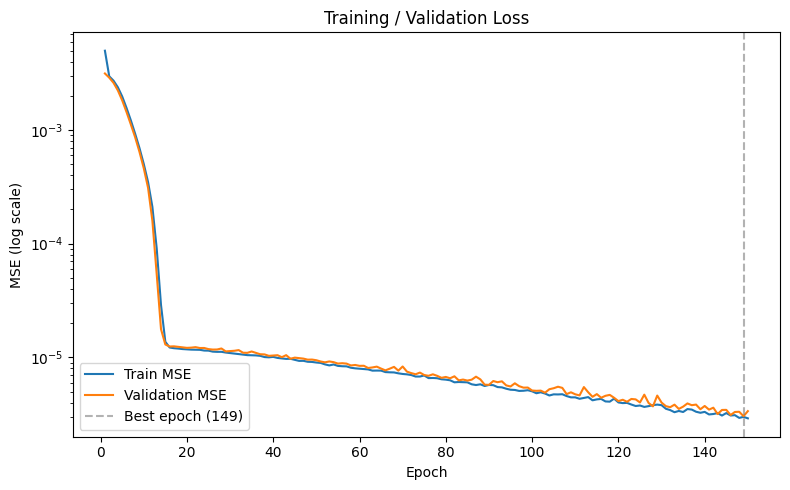

In [1]:
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split

# =====================================================
# CONFIG
# =====================================================
CSV_FILENAME = "polymer_training_dataset_step5_modified.csv"
TEST_SIZE = 0.2

# MODIFIED: Hidden width upgraded to 32.
# Total parameters: 1,647 (well balanced for 12,000 training patterns)
HIDDEN_DIM = 32

BATCH_SIZE = 32
EPOCHS = 150
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-6

LR_SCHEDULER_FACTOR = 0.5
LR_SCHEDULER_PATIENCE = 15
MIN_LR = 1e-6

RANDOM_SEED = 42

BEST_MODEL_FILENAME = "polymer_relaxation_step5_predictor_BEST.pth"
FINAL_MODEL_FILENAME = "polymer_relaxation_step5_predictor_FINAL.pth"
LOSS_HISTORY_FILENAME = "polymer_relaxation_step5_loss_history.csv"
LOSS_PLOT_FILENAME = "polymer_relaxation_step5_loss_curve.png"

# =====================================================
# RANDOM SEEDS (REPRODUCIBILITY)
# =====================================================
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

# =====================================================
# 1. LOAD DATASET
# =====================================================
print(f"Loading dataset from: {CSV_FILENAME}")
df = pd.read_csv(CSV_FILENAME)

print("\nConverting connector-wise table into per-configuration vectors...")
df = df.sort_values(["Configuration_ID", "Connector_ID"])

input_cols = [f"Q0_{axis}_mod" for axis in ['x', 'y', 'z']]
output_cols = [f"Q5_{axis}_mod" for axis in ['x', 'y', 'z']]

X_data_parts = df[input_cols].values
Y_data_parts = df[output_cols].values

num_configs = df["Configuration_ID"].nunique()
num_connectors = df["Connector_ID"].nunique()

X_data = X_data_parts.reshape(num_configs, num_connectors * 3).astype(np.float32)
Y_data = Y_data_parts.reshape(num_configs, num_connectors * 3).astype(np.float32)

input_dim = X_data.shape[1]
output_dim = Y_data.shape[1]

print(f" -> Input Matrix Shape  : {X_data.shape}")
print(f" -> Output Matrix Shape : {Y_data.shape}")

# =====================================================
# TRAIN / TEST SPLIT
# =====================================================
X_train, X_test, Y_train, Y_test = train_test_split(
    X_data,
    Y_data,
    test_size=TEST_SIZE,
    random_state=RANDOM_SEED,
)

print(
    f" -> Training instances: {X_train.shape[0]} "
    f"| Validation instances: {X_test.shape[0]} "
)

# =====================================================
# PYTORCH DATASETS
# =====================================================
train_dataset = TensorDataset(torch.tensor(X_train), torch.tensor(Y_train))
test_dataset = TensorDataset(torch.tensor(X_test), torch.tensor(Y_test))

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# =====================================================
# 2. NEURAL NETWORK ARCHITECTURE
# =====================================================
class PolymerRelaxationNN(nn.Module):
    def __init__(self, in_dim, out_dim, hidden_dim):
        super(PolymerRelaxationNN, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(in_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, out_dim),
            nn.Tanh()  # MODIFIED: Forces predictions inside physics-safe [-1, 1] bounds
        )

    def forward(self, x):
        return self.network(x)


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = PolymerRelaxationNN(input_dim, output_dim, HIDDEN_DIM).to(device)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"-> Total Trainable Parameters: {total_params:,}")

# =====================================================
# 3. LOSS FUNCTION, OPTIMIZER, SCHEDULER
# =====================================================
criterion = nn.MSELoss()
optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=LR_SCHEDULER_FACTOR,
    patience=LR_SCHEDULER_PATIENCE,
    min_lr=MIN_LR,
)

# =====================================================
# 4. TRAINING LOOP
# =====================================================
print(f"\nBeginning training for {EPOCHS} epochs on {device}...")

train_loss_history = []
val_loss_history = []
lr_history = []

best_val_loss = float("inf")
best_epoch = -1

for epoch in range(1, EPOCHS + 1):
    # ---------------- training phase ----------------
    model.train()
    running_loss = 0.0

    for batch_x, batch_y in train_loader:
        batch_x = batch_x.to(device)
        batch_y = batch_y.to(device)

        predictions = model(batch_x)
        loss = criterion(predictions, batch_y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * batch_x.size(0)

    epoch_loss = running_loss / len(train_loader.dataset)

    # ---------------- validation phase ----------------
    model.eval()
    val_loss = 0.0

    with torch.no_grad():
        for val_x, val_y in test_loader:
            val_x = val_x.to(device)
            val_y = val_y.to(device)

            val_preds = model(val_x)
            val_loss += criterion(val_preds, val_y).item() * val_x.size(0)

    epoch_val_loss = val_loss / len(test_loader.dataset)
    scheduler.step(epoch_val_loss)
    current_lr = optimizer.param_groups[0]["lr"]

    train_loss_history.append(epoch_loss)
    val_loss_history.append(epoch_val_loss)
    lr_history.append(current_lr)

    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        best_epoch = epoch
        torch.save(model.state_dict(), BEST_MODEL_FILENAME)

    if epoch == 1 or epoch % 10 == 0:
        print(
            f"Epoch {epoch:3d}/{EPOCHS} "
            f"| Training MSE: {epoch_loss:.8f} "
            f"| Validation MSE: {epoch_val_loss:.8f} "
            f"| Variable LR: {current_lr:.2e}"
        )

# =====================================================
# 5. SAVE FINAL MODEL + DIAGNOSTICS
# =====================================================
torch.save(model.state_dict(), FINAL_MODEL_FILENAME)

print("\nTraining complete!")
print(f"Saved best checkpoint as     : {BEST_MODEL_FILENAME} (epoch {best_epoch}, val MSE {best_val_loss:.8f})")

history_df = pd.DataFrame({
    "epoch": range(1, EPOCHS + 1),
    "train_mse": train_loss_history,
    "val_mse": val_loss_history,
    "lr": lr_history,
})
history_df.to_csv(LOSS_HISTORY_FILENAME, index=False)

plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["train_mse"], label="Train MSE")
plt.plot(history_df["epoch"], history_df["val_mse"], label="Validation MSE")
plt.axvline(best_epoch, color="gray", linestyle="--", alpha=0.6, label=f"Best epoch ({best_epoch})")
plt.yscale("log")
plt.xlabel("Epoch")
plt.ylabel("MSE (log scale)")
plt.title("Training / Validation Loss")
plt.legend()
plt.tight_layout()
plt.savefig(LOSS_PLOT_FILENAME, dpi=150)
print(f"Saved logs and diagnostics graphics.")

Effective timestep per NN call = 0.00500 sec
Total macro steps = 2,000,000
Bead Noise Std per step = 0.173205
Random initial configuration set. Initial End-to-End Distance: 17.4515

Neural network loaded successfully on: cpu
Running hybrid explicit-drift + thermal noise polymer simulation...
Simulation Progress: 10% | Time = 1000.00 sec
Simulation Progress: 20% | Time = 2000.00 sec
Simulation Progress: 30% | Time = 2999.99 sec
Simulation Progress: 40% | Time = 3999.99 sec
Simulation Progress: 50% | Time = 4999.99 sec
Simulation Progress: 60% | Time = 5999.99 sec
Simulation Progress: 70% | Time = 6999.99 sec
Simulation Progress: 80% | Time = 7999.99 sec
Simulation Progress: 90% | Time = 9000.00 sec
Simulation Progress: 100% | Time = 10000.00 sec

Simulation finished.

HYBRID THERMALIZED POLYMER SIMULATION RESULTS
Average <R>  = 21.6972
RMS distance = 21.7342


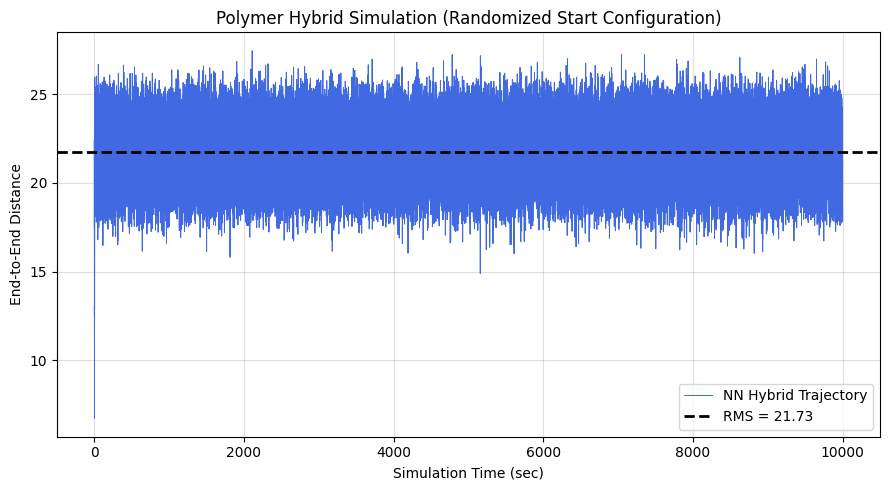

In [6]:
import random
import math
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# =====================================================
# RANDOM SEEDS
# =====================================================
np.random.seed(42)
torch.manual_seed(42)
random.seed(42)

# =====================================================
# CONFIG
# =====================================================
v = 100.0
dt = 0.001
total_simulation_time = 10000.0

NN_TIMESTEP = 5  # One NN call maps exactly 5 micro-steps
effective_dt = NN_TIMESTEP * dt
N_macro_steps = int(total_simulation_time / effective_dt)

MODEL_PATH = "polymer_relaxation_step5_predictor_BEST.pth"
SCALER_FILENAME = "global_min_max_params.npz"

# --- Macro-Step Noise Multipliers (Analytical Correlation Fix) ---
bead_noise_std = math.sqrt(6.0 * effective_dt)

print(f"Effective timestep per NN call = {effective_dt:.5f} sec")
print(f"Total macro steps = {N_macro_steps:,}")
print(f"Bead Noise Std per step = {bead_noise_std:.6f}")

# =====================================================
# INITIAL CONFIGURATION: RANDOMIZED 3D BEADS
# =====================================================
# Instead of a straight line, we build a random walk chain.
# Each spring component is initialized randomly such that the length is safely < 10.0.
pos = np.zeros((6, 3))
q_max_limit = math.sqrt(v)  # 10.0

for i in range(5):
    # Generate a random 3D unit vector
    random_direction = np.random.normal(0.0, 1.0, size=3)
    norm = np.linalg.norm(random_direction)
    if norm > 0:
        random_direction /= norm

    # Scale it to a safe initial length (e.g., 3.0, well within the equilibrium distribution)
    initial_length = 5.0
    random_Q = random_direction * initial_length

    # Propagate the next bead position relative to the previous one
    pos[i + 1, :] = pos[i, :] + random_Q

print(f"Random initial configuration set. Initial End-to-End Distance: {np.linalg.norm(pos[5] - pos[0]):.4f}")

# =====================================================
# STORAGE
# =====================================================
time_list = []
R_end_list = []

# =====================================================
# LOAD SCALERS (Isotropic Min-Max Scaling Mapping)
# =====================================================
scaler_data = np.load(SCALER_FILENAME)
global_abs_max = scaler_data["global_abs_max"]

def standardize(x, max_val):
    return x / max_val

def destandardize(x_scaled, max_val):
    return x_scaled * max_val

# =====================================================
# LOAD TRAINED MODEL
# =====================================================
class PolymerRelaxationNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(15, 32),
            nn.SiLU(),
            nn.Linear(32, 32),
            nn.SiLU(),
            nn.Linear(32, 15),
            nn.Tanh()
        )

    def forward(self, x):
        return self.network(x)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = PolymerRelaxationNN().to(device)
model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
model.eval()

print(f"\nNeural network loaded successfully on: {device}")
print("Running hybrid explicit-drift + thermal noise polymer simulation...")

# =====================================================
# MAIN SIMULATION LOOP
# =====================================================
for macro_step in range(N_macro_steps):
    current_time = macro_step * effective_dt

    # 1. PREPARE INPUT (connector vectors for NN)
    current_pos = pos.copy()
    current_Q = current_pos[1:] - current_pos[:-1] # Shape (5, 3), raw physical units

    # Standardize cleanly via global absolute maximum scaling feature mapping
    current_Q_scaled = standardize(current_Q.flatten(), global_abs_max)

    input_tensor = torch.tensor(
        current_Q_scaled, dtype=torch.float32
    ).unsqueeze(0).to(device)

    # ---------------------------------------------
    # 2. NN PREDICTION (Deterministic drift mapping)
    # ---------------------------------------------
    with torch.no_grad():
        pred_Q_scaled = model(input_tensor).cpu().numpy().squeeze(0)

    # De-normalize using matching physical scaling values back to physical space
    predicted_Q = destandardize(pred_Q_scaled, global_abs_max).reshape(5, 3)

    # ---------------------------------------------
    # 3. PHYSICAL FIX: STOCHASTIC CORRELATED NOISE INJECTION
    # ---------------------------------------------
    # Generate random displacements for the 6 individual beads first
    bead_thermal_noise = np.random.normal(0.0, bead_noise_std, size=(6, 3))

    # Calculate correlated connector noise: Delta W_i = Noise(Bead i+1) - Noise(Bead i)
    connector_thermal_noise = bead_thermal_noise[1:] - bead_thermal_noise[:-1]

    # Add correlated thermal noise to the deterministic network prediction
    predicted_Q += connector_thermal_noise

    # Explicit Physical Boundary Safety Check
    for i in range(5):
        q_mag = math.sqrt(predicted_Q[i, 0]**2 + predicted_Q[i, 1]**2 + predicted_Q[i, 2]**2)
        if q_mag >= q_max_limit:
            scale = (q_max_limit * 0.9999) / q_mag
            predicted_Q[i, 0] *= scale
            predicted_Q[i, 1] *= scale
            predicted_Q[i, 2] *= scale

    # Translate the absolute reference frame position of bead 0
    pos[0, :] += bead_thermal_noise[0, :]

    # Reconstruct absolute coordinate positions from our corrected connectors
    for i in range(5):
        pos[i + 1, :] = pos[i, :] + predicted_Q[i, :]

    # ---------------------------------------------
    # 4. TRACK PROGRESS METRICS
    # ---------------------------------------------
    R_end = np.linalg.norm(pos[5] - pos[0])
    R_end_list.append(R_end)
    time_list.append(current_time)

    if (macro_step + 1) % max(N_macro_steps // 10, 1) == 0:
        progress = ((macro_step + 1) / N_macro_steps) * 100
        print(f"Simulation Progress: {progress:.0f}% | Time = {current_time:.2f} sec")

print("\nSimulation finished.")

# =====================================================
# METRICS & EVALUATION
# =====================================================
R_end_array = np.array(R_end_list)
time_array = np.array(time_list)

avg_R = np.mean(R_end_array)
rms_R = np.sqrt(np.mean(R_end_array ** 2))

print("\n" + "=" * 50)
print("HYBRID THERMALIZED POLYMER SIMULATION RESULTS")
print("=" * 50)
print(f"Average <R>  = {avg_R:.4f}")
print(f"RMS distance = {rms_R:.4f}")
print("=" * 50)



# =====================================================
# PLOT GENERATION (Single Trajectory Plot)
# =====================================================
plt.figure(figsize=(9, 5))

plt.plot(time_list, R_end_list, linewidth=0.7, label="NN Hybrid Trajectory", color="royalblue")
plt.axhline(y=rms_R, linestyle="--", linewidth=2, color="black", label=f"RMS = {rms_R:.2f}")

plt.xlabel("Simulation Time (sec)")
plt.ylabel("End-to-End Distance")
plt.title("Polymer Hybrid Simulation (Randomized Start Configuration)")
plt.grid(True, alpha=0.4)
plt.legend()

plt.tight_layout()
plt.savefig("polymer_nn_hybrid_trajectory.png", dpi=300)
plt.show()